In [1]:
# ============================================================
# CELL 1: Install & Imports
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [2]:
# ============================================================
# CELL 2: Generate Synthetic Sales Dataset
# (Replace this with pd.read_csv('/kaggle/input/...') if you have a real dataset)
# ============================================================
np.random.seed(42)

date_range = pd.date_range(start='2020-01-01', end='2023-12-31', freq='D')
n = len(date_range)

categories = ['Electronics', 'Clothing', 'Food', 'Furniture', 'Sports']
regions = ['North', 'South', 'East', 'West']
segments = ['Retail', 'Wholesale', 'Online']

df = pd.DataFrame({
    'date': date_range,
    'product_category': np.random.choice(categories, n),
    'region': np.random.choice(regions, n),
    'customer_segment': np.random.choice(segments, n),
    'units_sold': np.random.randint(10, 500, n),
    'unit_price': np.random.uniform(10, 500, n).round(2),
})

# Add seasonality effect
df['month'] = df['date'].dt.month
seasonal_factor = 1 + 0.3 * np.sin((df['month'] - 3) * np.pi / 6)
df['sales_amount'] = (df['units_sold'] * df['unit_price'] * seasonal_factor).round(2)

# Add some noise/missing values intentionally for cleaning practice
df.loc[np.random.choice(df.index, 50), 'sales_amount'] = np.nan
df.loc[np.random.choice(df.index, 20), 'units_sold'] = -1  # corrupt values

print(f"Dataset shape: {df.shape}")
print(df.head())
df.to_csv('raw_sales_data.csv', index=False)
print("✅ Dataset saved as raw_sales_data.csv")

Dataset shape: (1461, 8)
        date product_category region customer_segment  units_sold  unit_price  \
0 2020-01-01        Furniture   West           Online         197      140.03   
1 2020-01-02           Sports   East        Wholesale         208      281.63   
2 2020-01-03             Food   East        Wholesale         312      107.76   
3 2020-01-04           Sports  South           Retail         336      154.04   
4 2020-01-05           Sports   West           Retail          -1      126.17   

   month  sales_amount  
0      1      20418.88  
1      1      43359.76  
2      1      24886.10  
3      1      38310.46  
4      1      15222.58  
✅ Dataset saved as raw_sales_data.csv


In [4]:
# ============================================================
# CELL 3: Data Cleaning & Preprocessing
# ============================================================

df = pd.read_csv('raw_sales_data.csv', parse_dates=['date'])

print("=== Initial Info ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Basic Stats ===")
print(df.describe())

# 1. Remove negative units_sold
print(f"\nRows with negative units_sold: {(df['units_sold'] < 0).sum()}")
df = df[df['units_sold'] >= 0]

# 2. Fill missing sales_amount with median per category
df['sales_amount'] = df.groupby('product_category')['sales_amount'].transform(
    lambda x: x.fillna(x.median())
)

# 3. Feature Engineering from date
df['year']        = df['date'].dt.year
df['month']       = df['date'].dt.month
df['day']         = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek
df['quarter']     = df['date'].dt.quarter
df['week']        = df['date'].dt.isocalendar().week.astype(int)
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)

# 4. Encode categoricals
df['category_enc'] = pd.Categorical(df['product_category']).codes
df['region_enc']   = pd.Categorical(df['region']).codes
df['segment_enc']  = pd.Categorical(df['customer_segment']).codes

print("\n Cleaned dataset shape:", df.shape)
print(df.isnull().sum())
df.to_csv('cleaned_sales_data.csv', index=False)
print(" Saved cleaned_sales_data.csv")

=== Initial Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              1461 non-null   datetime64[ns]
 1   product_category  1461 non-null   object        
 2   region            1461 non-null   object        
 3   customer_segment  1461 non-null   object        
 4   units_sold        1461 non-null   int64         
 5   unit_price        1461 non-null   float64       
 6   month             1461 non-null   int64         
 7   sales_amount      1412 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 91.4+ KB
None

=== Missing Values ===
date                 0
product_category     0
region               0
customer_segment     0
units_sold           0
unit_price           0
month                0
sales_amount        49
dtype: int64

=== Basic Stats ===
    

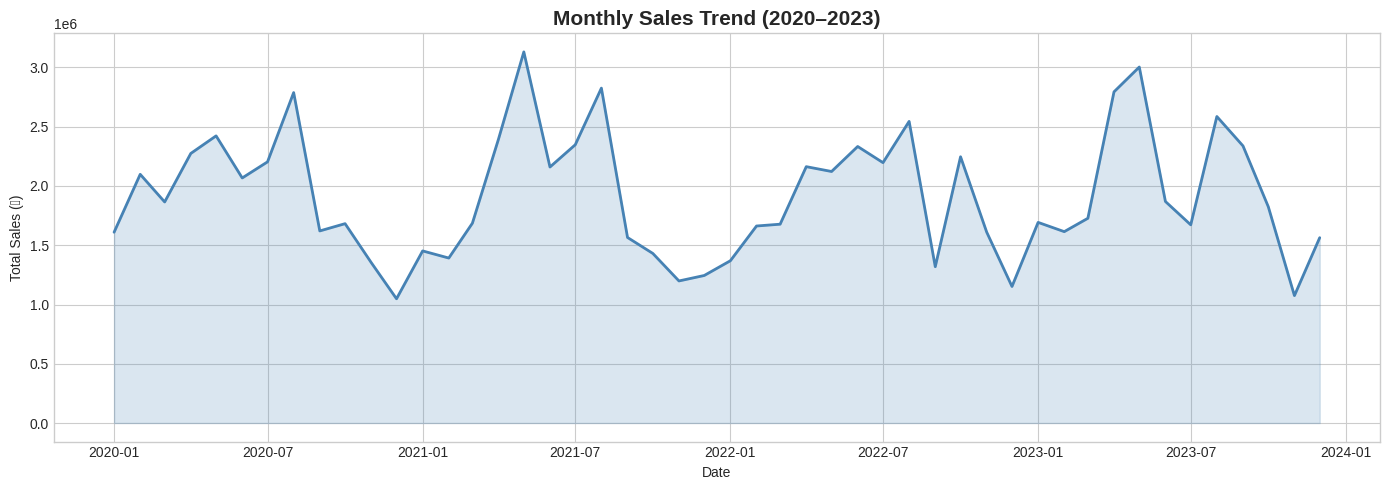

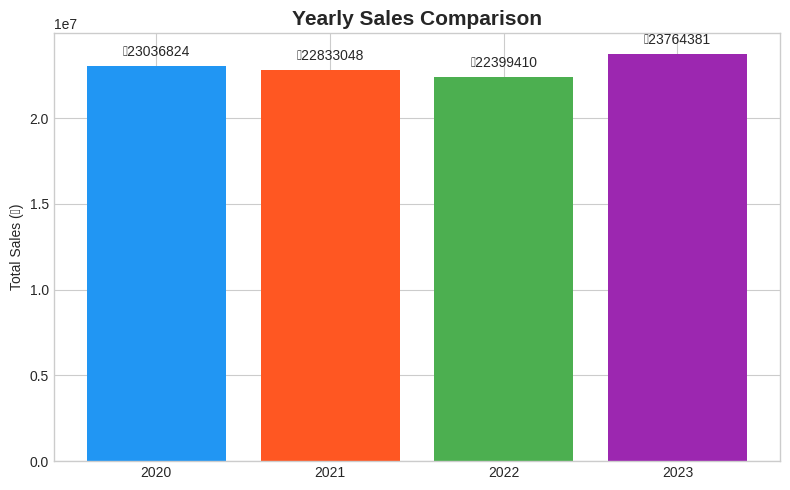

In [5]:
# ============================================================
# CELL 4: EDA — Sales Trends
# ============================================================

# Monthly aggregated sales
monthly = df.groupby(['year', 'month'])['sales_amount'].sum().reset_index()
monthly['period'] = pd.to_datetime(monthly[['year', 'month']].assign(day=1))

plt.figure(figsize=(14, 5))
plt.plot(monthly['period'], monthly['sales_amount'], color='steelblue', linewidth=2)
plt.fill_between(monthly['period'], monthly['sales_amount'], alpha=0.2, color='steelblue')
plt.title('Monthly Sales Trend (2020–2023)', fontsize=15, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales (₹)')
plt.tight_layout()
plt.savefig('monthly_sales_trend.png', dpi=150)
plt.show()

# Yearly comparison
yearly = df.groupby('year')['sales_amount'].sum().reset_index()
plt.figure(figsize=(8, 5))
bars = plt.bar(yearly['year'].astype(str), yearly['sales_amount'],
               color=['#2196F3', '#FF5722', '#4CAF50', '#9C27B0'])
plt.bar_label(bars, fmt='₹%.0f', padding=5)
plt.title('Yearly Sales Comparison', fontsize=15, fontweight='bold')
plt.ylabel('Total Sales (₹)')
plt.tight_layout()
plt.savefig('yearly_sales_comparison.png', dpi=150)
plt.show()

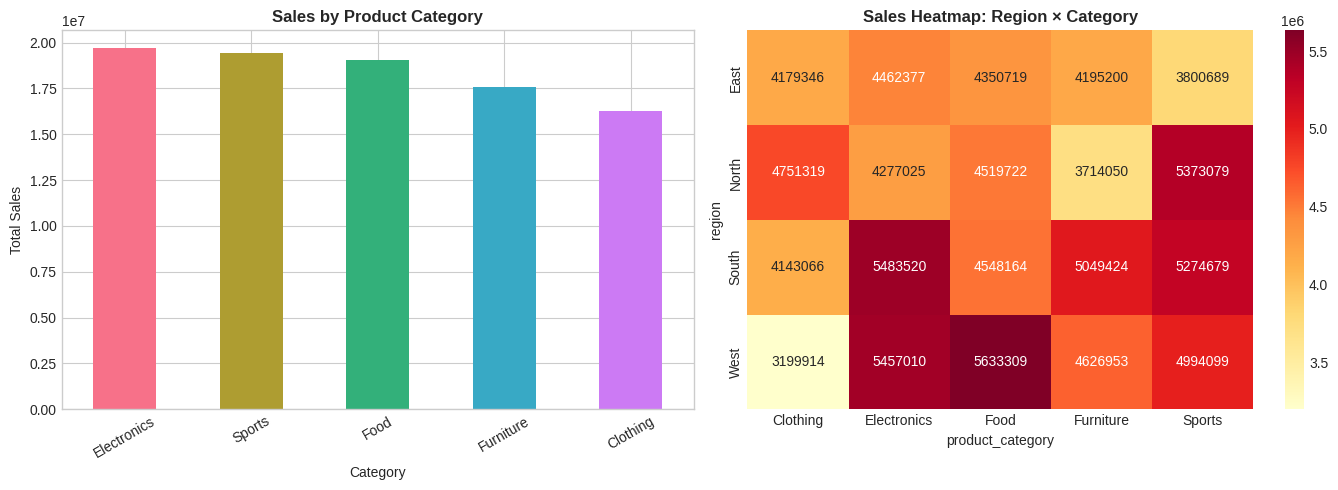

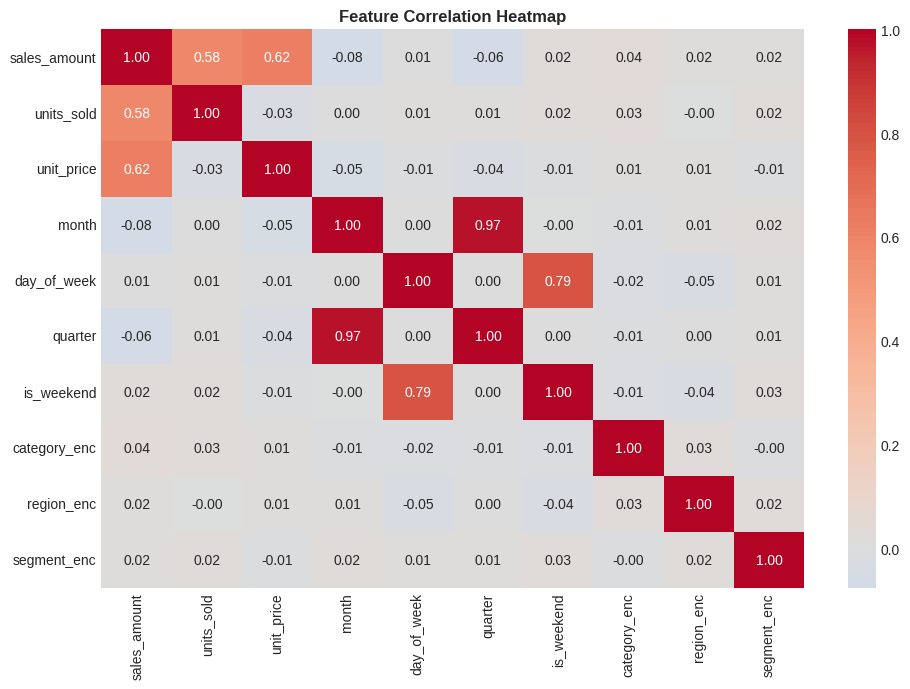

In [6]:
# ============================================================
# CELL 5: EDA — Category & Region Breakdown
# ============================================================

# Category performance
cat_sales = df.groupby('product_category')['sales_amount'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_sales.plot(kind='bar', ax=axes[0], color=sns.color_palette("husl", len(cat_sales)))
axes[0].set_title('Sales by Product Category', fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Total Sales')
axes[0].tick_params(axis='x', rotation=30)

# Region heatmap
pivot = df.pivot_table(values='sales_amount', index='region',
                        columns='product_category', aggfunc='sum')
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Sales Heatmap: Region × Category', fontweight='bold')

plt.tight_layout()
plt.savefig('category_region_analysis.png', dpi=150)
plt.show()

# Correlation heatmap
num_cols = ['sales_amount', 'units_sold', 'unit_price', 'month',
            'day_of_week', 'quarter', 'is_weekend',
            'category_enc', 'region_enc', 'segment_enc']
plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

In [9]:
# ============================================================
# CELL 1: Load Data & Setup
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('cleaned_sales_data.csv', parse_dates=['date'])

FEATURES = ['month', 'year', 'day_of_week', 'quarter', 'week',
            'is_weekend', 'units_sold', 'unit_price',
            'category_enc', 'region_enc', 'segment_enc']
TARGET = 'sales_amount'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # time-ordered split
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (1152, 11), Test size: (289, 11)


In [10]:
# ============================================================
# CELL 2: Train Models
# ============================================================

models = {
    "Linear Regression":    LinearRegression(),
    "Random Forest":        RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting":    GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}

for name, model in models.items():
    if name == "Linear Regression":
        model.fit(X_train_sc, y_train)
        preds = model.predict(X_test_sc)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'predictions': preds}
    print(f"\n📊 {name}")
    print(f"   MAE  : ₹{mae:,.2f}")
    print(f"   RMSE : ₹{rmse:,.2f}")
    print(f"   R²   : {r2:.4f}")


📊 Linear Regression
   MAE  : ₹21,180.30
   RMSE : ₹28,529.17
   R²   : 0.7304

📊 Random Forest
   MAE  : ₹8,308.90
   RMSE : ₹21,647.35
   R²   : 0.8448

📊 Gradient Boosting
   MAE  : ₹8,109.98
   RMSE : ₹21,914.59
   R²   : 0.8410


📊 ARIMA (Time Series)
   MAE  : ₹533,011.93
   RMSE : ₹612,417.94
   R²   : -0.5055


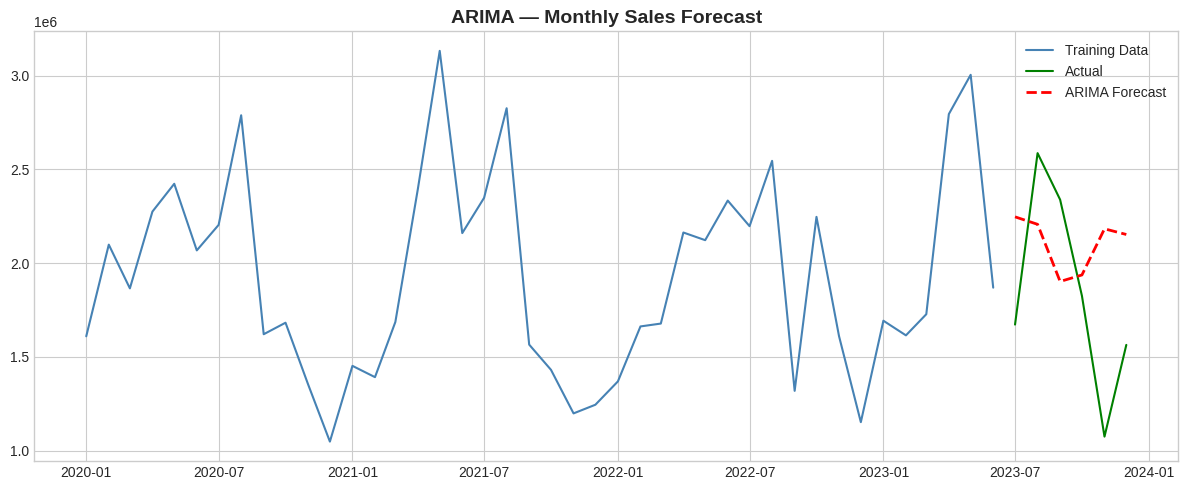

In [11]:
# ============================================================
# CELL 3: ARIMA Time Series Forecasting
# ============================================================
from statsmodels.tsa.arima.model import ARIMA

# Aggregate to monthly for ARIMA
monthly_ts = df.groupby('date')['sales_amount'].sum()
monthly_ts = monthly_ts.resample('MS').sum()

train_ts = monthly_ts[:-6]
test_ts  = monthly_ts[-6:]

arima_model = ARIMA(train_ts, order=(2, 1, 2))
arima_fit   = arima_model.fit()

forecast = arima_fit.forecast(steps=6)

arima_mae  = mean_absolute_error(test_ts, forecast)
arima_rmse = np.sqrt(mean_squared_error(test_ts, forecast))
arima_r2   = r2_score(test_ts, forecast)

print("📊 ARIMA (Time Series)")
print(f"   MAE  : ₹{arima_mae:,.2f}")
print(f"   RMSE : ₹{arima_rmse:,.2f}")
print(f"   R²   : {arima_r2:.4f}")

plt.figure(figsize=(12, 5))
plt.plot(train_ts.index, train_ts.values, label='Training Data', color='steelblue')
plt.plot(test_ts.index,  test_ts.values,  label='Actual',        color='green')
plt.plot(test_ts.index,  forecast.values, label='ARIMA Forecast',
         color='red', linestyle='--', linewidth=2)
plt.title('ARIMA — Monthly Sales Forecast', fontweight='bold', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('arima_forecast.png', dpi=150)
plt.show()


=== Model Comparison ===
                          MAE        RMSE      R2
Linear Regression  21180.3040  28529.1700  0.7304
Random Forest       8308.9016  21647.3494  0.8448
Gradient Boosting   8109.9774  21914.5904  0.8410


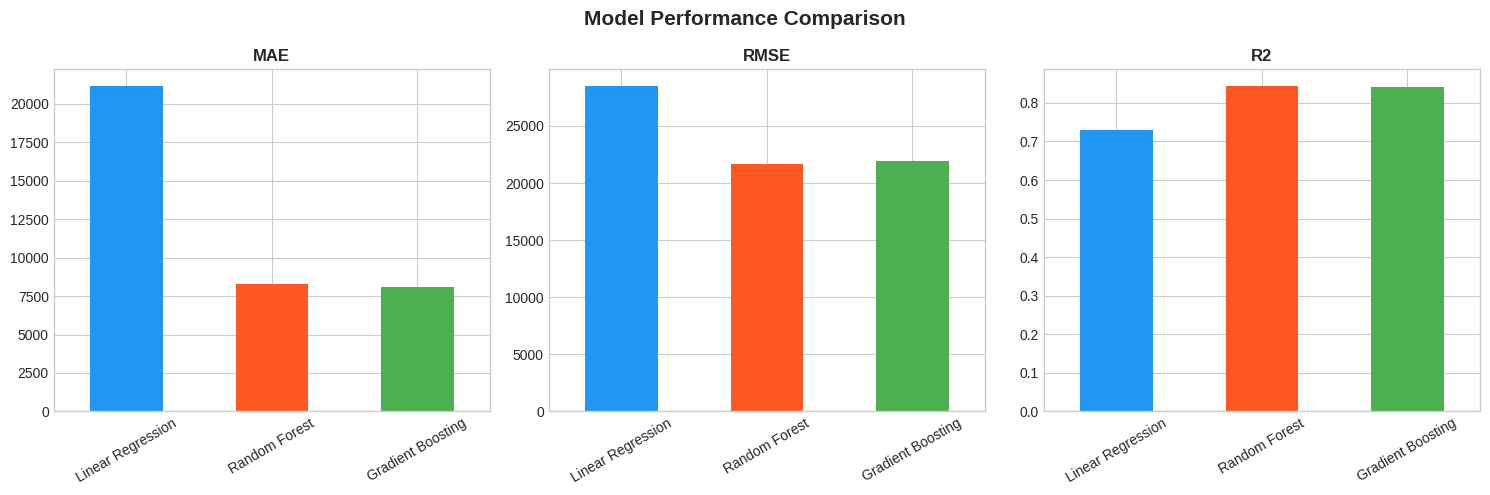

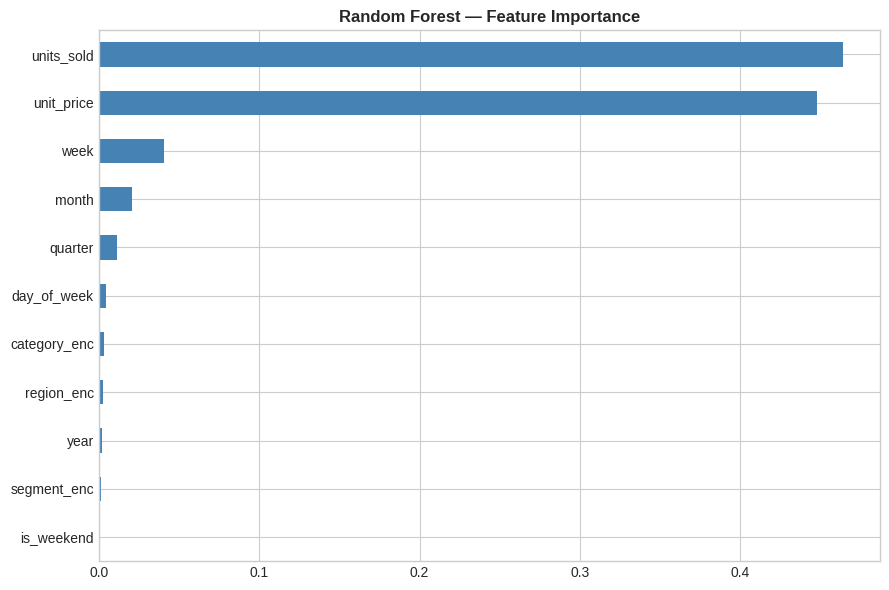

In [12]:
# ============================================================
# CELL 4: Model Comparison & Feature Importance
# ============================================================

# Comparison bar chart
metrics_df = pd.DataFrame({
    name: {'MAE': v['MAE'], 'RMSE': v['RMSE'], 'R2': v['R2']}
    for name, v in results.items()
}).T

print("\n=== Model Comparison ===")
print(metrics_df.round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    metrics_df[metric].plot(kind='bar', ax=ax,
        color=['#2196F3', '#FF5722', '#4CAF50'])
    ax.set_title(metric, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

# Feature importance (Random Forest)
rf_model = models["Random Forest"]
feat_imp = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
plt.figure(figsize=(9, 6))
feat_imp.plot(kind='barh', color='steelblue')
plt.title('Random Forest — Feature Importance', fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

🏆 Best Model: Random Forest (R² = 0.8448)


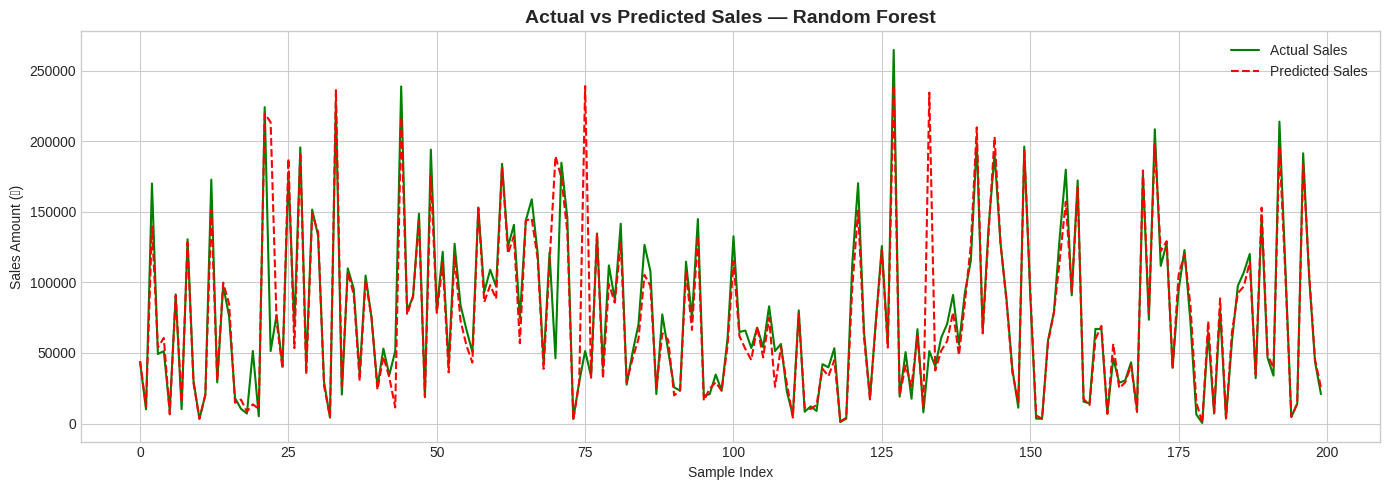

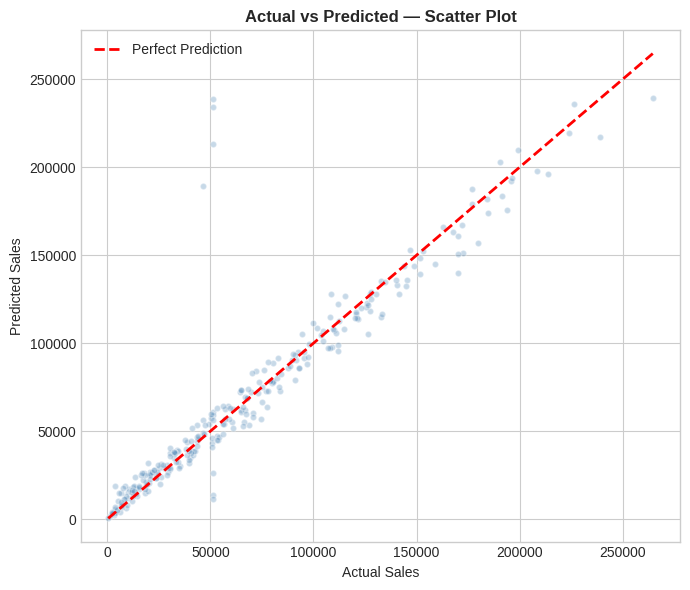

In [13]:
# ============================================================
# CELL 5: Predicted vs Actual — Best Model
# ============================================================

best_model_name = max(results, key=lambda k: results[k]['R2'])
best_preds = results[best_model_name]['predictions']

print(f"🏆 Best Model: {best_model_name} (R² = {results[best_model_name]['R2']:.4f})")

plt.figure(figsize=(14, 5))
plt.plot(y_test.values[:200],  label='Actual Sales',    color='green',  linewidth=1.5)
plt.plot(best_preds[:200],     label='Predicted Sales', color='red',
         linestyle='--', linewidth=1.5)
plt.title(f'Actual vs Predicted Sales — {best_model_name}', fontweight='bold', fontsize=14)
plt.xlabel('Sample Index')
plt.ylabel('Sales Amount (₹)')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

# Scatter plot
plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_preds, alpha=0.3, color='steelblue', edgecolors='white', s=20)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted — Scatter Plot', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('scatter_actual_vs_predicted.png', dpi=150)
plt.show()

In [14]:
# ============================================================
# Interactive Visualizations with Plotly
# ============================================================
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv('cleaned_sales_data.csv', parse_dates=['date'])

# 1. Interactive Monthly Trend
monthly = df.groupby(df['date'].dt.to_period('M'))['sales_amount'].sum().reset_index()
monthly['date'] = monthly['date'].dt.to_timestamp()

fig = px.line(monthly, x='date', y='sales_amount',
              title='📈 Monthly Sales Trend',
              labels={'sales_amount': 'Sales (₹)', 'date': 'Month'},
              template='plotly_white')
fig.update_traces(line=dict(color='royalblue', width=2.5))
fig.show()

# 2. Sales by Category (interactive pie)
cat = df.groupby('product_category')['sales_amount'].sum().reset_index()
fig2 = px.pie(cat, names='product_category', values='sales_amount',
              title='🛒 Sales Share by Category',
              hole=0.4, template='plotly_white')
fig2.show()

# 3. Region-wise monthly heatmap
df['month_name'] = df['date'].dt.strftime('%b %Y')
region_monthly = df.groupby(['region', df['date'].dt.to_period('M')])['sales_amount'].sum().reset_index()
region_monthly['date'] = region_monthly['date'].dt.to_timestamp()

fig3 = px.bar(region_monthly, x='date', y='sales_amount', color='region',
              barmode='group', title='🌍 Regional Sales Over Time',
              template='plotly_white')
fig3.show()

# 4. Category sales over quarters
df['quarter_label'] = df['year'].astype(str) + ' Q' + df['quarter'].astype(str)
q_cat = df.groupby(['quarter_label', 'product_category'])['sales_amount'].sum().reset_index()
fig4 = px.bar(q_cat, x='quarter_label', y='sales_amount', color='product_category',
              title='📦 Category Performance by Quarter',
              template='plotly_white')
fig4.show()

print("✅ All interactive plots rendered!")

✅ All interactive plots rendered!
